# Shadow Model Attack

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import torch
import mia_utils
from baseline.config import Config, CFG
import pandas as pd

## Obtain Shadow Model Logits

In [2]:
# Load data used to train and evaluate `shadow` (DenseNet121) model
SHADOW_DATA_PATH = CFG.project_root / 'shadow_data_small'
SHADOW_MODEL_PATH = CFG.project_root / 'checkpoints/shadow_model/last.ckpt'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
member_logits, member_y, non_logits, non_y = mia_utils.get_model_outputs(SHADOW_DATA_PATH, SHADOW_MODEL_PATH, device)

Loading datamodule...
Datamodule loaded.

Loading Model...


/s/chopin/k/grad/sofia02c/.local/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Model loaded.

Creating member/non-members...
Calculating model outputs...


Extracting logits: 100%|████████| 165/165 [01:14<00:00,  2.20it/s]


## Build Shadow Datasets to Train Attack Models

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
shadow_datasets = mia_utils.build_mia_attack_datasets(member_logits, member_y, non_logits, non_y)

## Train Attack Models with Shadow Data

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [6]:
models = {
    'Logistic Regression': (LogisticRegression, {'max_iter': 1000}),
    'Random Forest': (RandomForestClassifier, {'n_estimators': 200, 'random_state': 1}),
    'MLP': (MLPClassifier, {'hidden_layer_sizes': (64, 32), 'max_iter': 300, "random_state": 1})
}

In [7]:
shadow_results = {}
attack_models = {}

for model_name, (model, kwargs) in models.items():
    print(f'Results for {model_name}')
    shadow_results[model_name] = {}
    attack_models[model_name] = {}
    for dataset_name, (X, y) in shadow_datasets.items():
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
        clf = mia_utils.train_attack_model(X_train, y_train, model, kwargs)
        attack_models[model_name][dataset_name] = clf
        shadow_results[model_name][dataset_name] = mia_utils.evaluate_attack_model(clf, X_test, y_test)

Results for Logistic Regression
Results for Random Forest
Results for MLP


In [8]:
def summarize_results(results_df):
    rows = []
    
    for name, result in results_df.items():
        rows.append({
            'Method': name,
            'AUC': result['auc'],
            'Balanced accuracy': result['balanced_accuracy'],
            'TPR @ 0.10 FPR': result['tpr_at_0.1_fpr'],
            'Best Threshold': result['best_threshold'],
            'TPR @ Best Threshold': result['best_tpr'],
            'FPR @ Best Threshold': result['best_fpr'],
        })
    
    return pd.DataFrame(rows)

In [9]:
shadow_results_df = summarize_results(shadow_results['Logistic Regression'])
shadow_results_df

,Method,AUC,Balanced accuracy,TPR @ 0.10 FPR,Best Threshold,TPR @ Best Threshold,FPR @ Best Threshold
0,Logits,0.633992,0.500579,0.205083,0.791120,0.600548,0.398095
1,Loss,0.507291,0.500000,0.077997,0.781619,0.853975,0.789524
2,Confidence,0.524832,0.500000,0.088961,0.787607,0.673810,0.601905
3,Entropy,0.536368,0.500000,0.109145,0.787108,0.720409,0.643810
4,All,0.663017,0.507032,0.242213,0.817527,0.519561,0.271429


In [10]:
shadow_results_df = summarize_results(shadow_results['Random Forest'])
shadow_results_df

,Method,AUC,Balanced accuracy,TPR @ 0.10 FPR,Best Threshold,TPR @ Best Threshold,FPR @ Best Threshold
0,Logits,0.656988,0.505875,0.256666,0.780,0.613257,0.380952
1,Loss,0.516244,0.507987,0.000000,0.880,0.626464,0.592381
2,Confidence,0.505794,0.496916,0.000000,0.905,0.575380,0.550476
3,Entropy,0.499173,0.491259,0.000000,0.980,0.415400,0.401905
4,All,0.666270,0.518438,0.246200,0.785,0.607526,0.359048


In [11]:
shadow_results_df = summarize_results(shadow_results['MLP'])
shadow_results_df

,Method,AUC,Balanced accuracy,TPR @ 0.10 FPR,Best Threshold,TPR @ Best Threshold,FPR @ Best Threshold
0,Logits,0.651144,0.523905,0.254672,0.799459,0.603289,0.380952
1,Loss,0.569180,0.500000,0.155495,0.805376,0.390232,0.280000
2,Confidence,0.524832,0.500000,0.088961,0.809179,0.673810,0.601905
3,Entropy,0.540101,0.500000,0.113631,0.804561,0.729130,0.648571
4,All,0.683660,0.531795,0.278595,0.832792,0.525293,0.247619


## Evaluate on Victim Data

In [12]:
# Load data used to train and evaluate `victim` (DenseNet121) model
VICTIM_DATA_PATH = CFG.data_root
VICTIM_MODEL_PATH = CFG.project_root / 'last.ckpt'
member_logits, member_y, non_logits, non_y = mia_utils.get_model_outputs(VICTIM_DATA_PATH, VICTIM_MODEL_PATH, device)

Loading datamodule...
Datamodule loaded.

Loading Model...


/s/chopin/k/grad/sofia02c/.local/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Model loaded.

Creating member/non-members...
Calculating model outputs...


Extracting logits: 100%|████████| 174/174 [01:19<00:00,  2.18it/s]


In [13]:
victim_datasets = mia_utils.build_mia_attack_datasets(member_logits, member_y, non_logits, non_y)

In [14]:
victim_results = {}

for model_name in models.keys():
    print(f'Results for {model_name}')
    victim_results[model_name] = {}
    for dataset_name, (X, y) in victim_datasets.items():
        clf = attack_models[model_name][dataset_name] 
        victim_results[model_name][dataset_name] = mia_utils.evaluate_attack_model(clf, X, y)

Results for Logistic Regression
Results for Random Forest
Results for MLP


In [15]:
victim_results_df = summarize_results(victim_results['Logistic Regression'])
victim_results_df

,Method,AUC,Balanced accuracy,TPR @ 0.10 FPR,Best Threshold,TPR @ Best Threshold,FPR @ Best Threshold
0,Logits,0.453817,0.499329,0.073903,0.979209,0.001145,0.000903
1,Loss,0.517560,0.500000,0.137023,0.786105,0.190219,0.150623
2,Confidence,0.480355,0.500000,0.101479,0.823056,0.177767,0.171573
3,Entropy,0.481975,0.500000,0.108826,0.823997,0.174046,0.164530
4,All,0.454959,0.496408,0.069418,0.986752,0.001050,0.000542


In [16]:
victim_results_df = summarize_results(victim_results['Random Forest'])
victim_results_df

,Method,AUC,Balanced accuracy,TPR @ 0.10 FPR,Best Threshold,TPR @ Best Threshold,FPR @ Best Threshold
0,Logits,0.495211,0.499680,0.111116,0.795000,0.187118,0.175366
1,Loss,0.503055,0.505245,0.162071,0.630000,0.683588,0.672205
2,Confidence,0.501575,0.497774,0.000000,0.975833,0.330534,0.318042
3,Entropy,0.493655,0.497254,0.000000,0.735000,0.764456,0.764313
4,All,0.500176,0.500697,0.103435,0.820000,0.144513,0.134911


In [17]:
victim_results_df = summarize_results(victim_results['MLP'])
victim_results_df

,Method,AUC,Balanced accuracy,TPR @ 0.10 FPR,Best Threshold,TPR @ Best Threshold,FPR @ Best Threshold
0,Logits,0.476776,0.498322,0.090315,0.997283,0.015506,0.011378
1,Loss,0.515077,0.500000,0.124761,0.777577,0.264027,0.229185
2,Confidence,0.480355,0.500000,0.101479,0.833341,0.177767,0.171573
3,Entropy,0.481976,0.500000,0.108826,0.837266,0.174046,0.164530
4,All,0.466044,0.498758,0.086689,0.999990,0.013740,0.011197


## ROC Curves - Summary

In [18]:
results_by_model = {}

for model_name in shadow_results.keys():
    results_by_model[model_name] = {}

    for data_name in shadow_results[model_name].keys():
        results_by_model[model_name][data_name] = {
            'shadow': shadow_results[model_name][data_name],
            'victim': victim_results[model_name][data_name]
        }

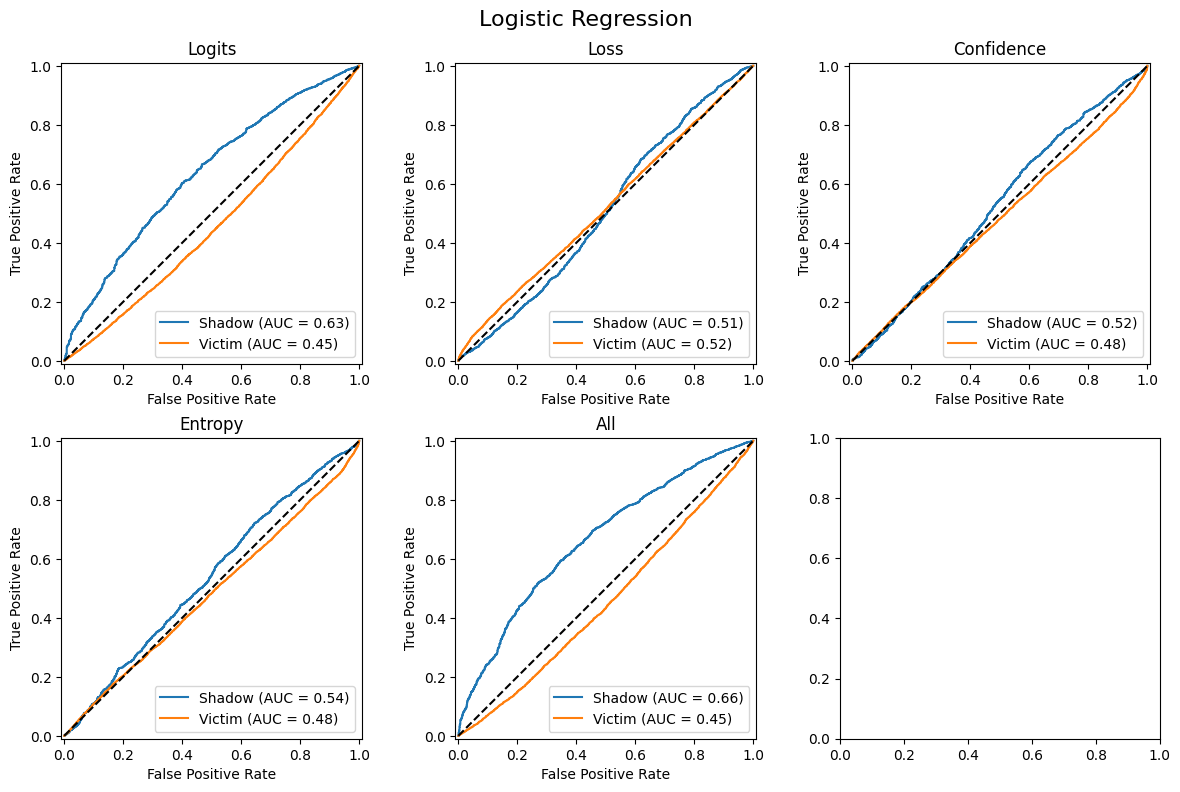

In [19]:
mia_utils.plot_attack_roc(results_by_model['Logistic Regression'], 'Logistic Regression')

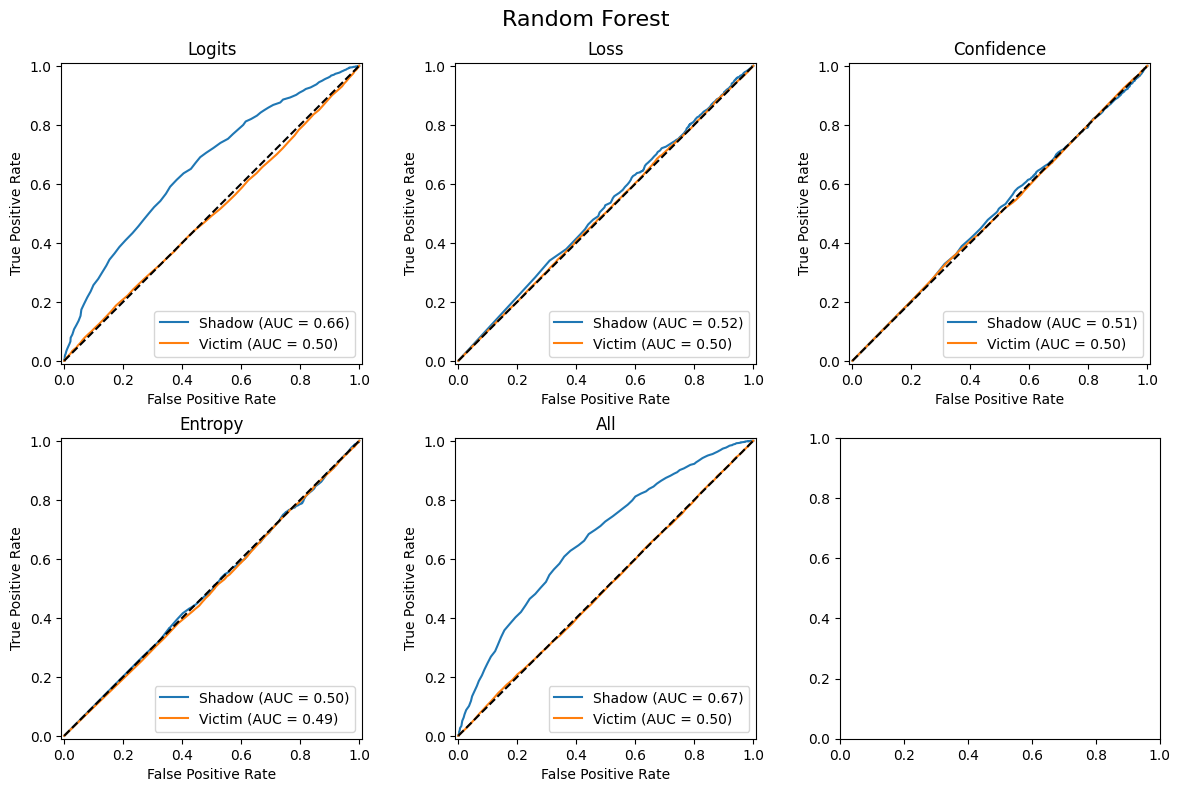

In [20]:
mia_utils.plot_attack_roc(results_by_model['Random Forest'], 'Random Forest')

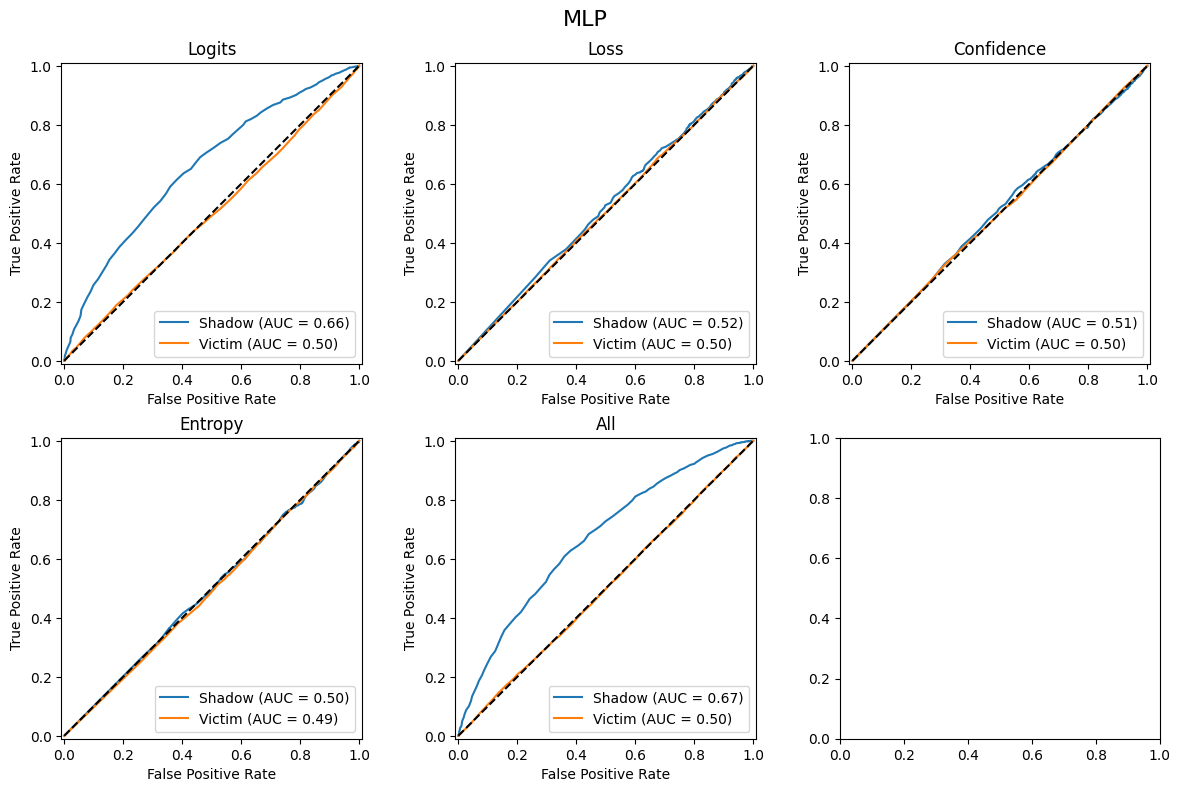

In [21]:
mia_utils.plot_attack_roc(results_by_model['Random Forest'], 'MLP')